# Day 16: KV Cache Prefix Caching and Cache-Aware Routing
> *Inference Engineering* — Chapter 5.3 | Philip Kiely, Baseten Books 2026

**Layer:** Runtime (with Infrastructure implications)
**Prerequisites:** Day 05 (KV cache basics), Day 06 (arithmetic intensity)


## Why this matters

Every inference engine builds a key-value (KV) cache during prefill. Without it, each new token would recompute attention over the full sequence. The default KV cache lives and dies with a single request. But if two requests share a prefix — a system prompt, a codebase, a conversation history — the already-computed KV entries can be reused, skipping prefill on the shared tokens. That is prefix caching.

Two follow-on problems appear immediately. First, KV cache is big and VRAM is small, so a memory hierarchy becomes necessary (G1 device memory, G2 host memory, G3 local SSD, G4 networked SSD). Second, in a multi-replica deployment, the cache lives on whichever replica served the first request — so the router needs to know about cache affinity. That is cache-aware routing.

This notebook works through all three: the token-level mechanics of prefix matching, the cache size math that bounds how much prefix can be kept, and a routing simulation that shows why cache-aware dispatch beats round-robin when traffic has shared prefixes.


In [1]:
# Prefix caching demos use a real tokenizer to show token-level matching.
# Falls back gracefully if transformers is not installed.
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, OrderedDict

try:
    from transformers import AutoTokenizer
    TOK = AutoTokenizer.from_pretrained("gpt2")
    HAS_TOKENIZER = True
    print(f"Loaded gpt2 tokenizer: vocab size = {TOK.vocab_size}")
except Exception as e:
    HAS_TOKENIZER = False
    print(f"Tokenizer unavailable ({e}); will use whitespace tokens as fallback")

np.random.seed(42)


/home/nvidia/src/github.com/elizabetht/100-days-of-inference/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded gpt2 tokenizer: vocab size = 50257


## 1. The autoregressive constraint makes prefix caching possible

LLMs are autoregressive — each token's hidden state depends on every previous token. Rewrite one token near the start of the prompt and every downstream KV entry changes. That is why arbitrary mid-sequence fragments cannot be cached without correction: positional embeddings and residual state drift.

But prefixes are safe. If requests `A` and `B` share the first `k` tokens exactly, then the KV entries for positions `[0, k)` are bit-identical. No drift. Prefill runs once, the cache is stored, and it gets replayed for any future request with the same prefix.

```
request 1:  [T0] [T1] [T2] [T3] [T4]      <-- prefill all 5 tokens, store KV
request 2:  [T0] [T1] [T2] [Tx] [Ty]      <-- read KV[0..3), prefill only Tx, Ty
                            ^
                         first novel token (prefix ends here)
```

The prefix ends at the *first* non-matching token. One changed token at position 0 wipes out the savings entirely, no matter how similar the rest of the sequence looks to a human reader. This is the key lesson of context engineering: **push novel tokens as late in the context as possible.**


In [2]:
# How much does KV cache cost? The formula:
#   bytes_per_token = num_layers * 2 * num_kv_heads * head_dim * dtype_bytes
#                                  ^ one K and one V per layer
#
# For GQA (grouped query attention), num_kv_heads < num_attention_heads,
# which cuts KV cache size. Llama-3 uses 8 KV heads regardless of model size.

def kv_cache_per_token(num_layers, num_kv_heads, head_dim, dtype_bytes=2):
    return num_layers * 2 * num_kv_heads * head_dim * dtype_bytes

models = [
    ("GPT-2 small",    12, 12, 64,  2),    # no GQA, FP16
    ("Llama-3 8B",     32, 8,  128, 2),
    ("Llama-3 70B",    80, 8,  128, 2),
    ("Llama-3 405B",  126, 8,  128, 2),
    ("DeepSeek-V3",   61, 128, 128, 1),   # 128 KV heads, FP8
]

print(f"{'model':<18}{'KB/token':>12}{'32K ctx':>12}{'128K ctx':>14}")
print("-" * 56)
for name, L, H, D, B in models:
    per_tok = kv_cache_per_token(L, H, D, B)
    mb_32k = per_tok * 32_768 / (1024**2)
    gb_128k = per_tok * 131_072 / (1024**3)
    print(f"{name:<18}{per_tok/1024:>10.1f} KB  {mb_32k:>8.1f} MB  {gb_128k:>10.2f} GB")


model                 KB/token     32K ctx      128K ctx
--------------------------------------------------------
GPT-2 small             36.0 KB    1152.0 MB        4.50 GB
Llama-3 8B             128.0 KB    4096.0 MB       16.00 GB
Llama-3 70B            320.0 KB   10240.0 MB       40.00 GB
Llama-3 405B           504.0 KB   16128.0 MB       63.00 GB
DeepSeek-V3           1952.0 KB   62464.0 MB      244.00 GB


## 2. Prefix matching is at the token level, not the character level

Book Figure 5.7 draws the canonical pair:

```
    Weather  in  SF   ?       <-- request 1 (prefill all 4, store KV)
    Weather  in  NYC  ?       <-- request 2

    match:  [Weather] [in]
    miss:   [NYC]
    discard: [?]              <-- cannot be reused because position 3's
                                  context depends on the novel token at pos 2
```

The `?` in both requests is the same *token*, but prefix caching stops at the first miss. Everything after the first non-matching token must be recomputed from scratch, because its KV entry depends on the tokens before it.

Flip the template so the novel token (`SF` vs `NYC`) lands early and the savings vanish. Flip it so the novel token lands late and almost everything gets reused. The numbers below make this concrete.


In [3]:
# Compute the longest common *token* prefix between two prompts.

def token_ids(text):
    if HAS_TOKENIZER:
        return TOK.encode(text)
    return text.split()

def longest_common_prefix(a_ids, b_ids):
    k = 0
    for x, y in zip(a_ids, b_ids):
        if x == y:
            k += 1
        else:
            break
    return k

def describe_match(label_a, a, label_b, b):
    a_ids, b_ids = token_ids(a), token_ids(b)
    k = longest_common_prefix(a_ids, b_ids)
    total_a, total_b = len(a_ids), len(b_ids)
    saved_frac = k / total_a if total_a else 0.0
    print(f"  {label_a!r:>30} -> {total_a} tokens")
    print(f"  {label_b!r:>30} -> {total_b} tokens")
    print(f"  shared prefix: {k} tokens  =>  prefill savings on second request: {saved_frac:.1%}")
    if HAS_TOKENIZER and k > 0:
        shared = TOK.decode(a_ids[:k])
        print(f"  shared slice decoded: {shared!r}")
    print()

print("Pair A (book Figure 5.7) -- novel token in the middle:")
describe_match("Weather in SF?", "Weather in SF?", "Weather in NYC?", "Weather in NYC?")

print("Pair B (book Figure 5.8) -- novel token at the START:")
describe_match("SF weather today?", "SF weather today?", "NYC weather today?", "NYC weather today?")


Pair A (book Figure 5.7) -- novel token in the middle:
                'Weather in SF?' -> 4 tokens
               'Weather in NYC?' -> 4 tokens
  shared prefix: 2 tokens  =>  prefill savings on second request: 50.0%
  shared slice decoded: 'Weather in'

Pair B (book Figure 5.8) -- novel token at the START:
             'SF weather today?' -> 4 tokens
            'NYC weather today?' -> 5 tokens
  shared prefix: 0 tokens  =>  prefill savings on second request: 0.0%



## 3. Context engineering for TTFT

The autoregressive property turns prompt template design into a cache optimization problem. A naive chatbot that builds prompts like:

```
User {user_name}. Assistant instructions and docs: <10K tokens>.
Question: {user_question}
```

loses every cache hit because `{user_name}` sits at position 0. Move the user name to the end and suddenly the 10K-token document block becomes a reusable prefix shared across every user on the platform. In complex system-prompt-heavy applications (agents, RAG, customer chatbots) this single restructuring can cut time-to-first-token (TTFT) by an order of magnitude.

The rule is simple: **variable parts of the prompt go last.**


In [4]:
# Simulate TTFT for two prompt templates on a Llama-3 8B-scale model.
# Prefill TTFT is roughly proportional to the number of tokens that must be prefilled.
# Assume a per-token prefill cost based on arithmetic-intensity-limited throughput.

PREFILL_TOKS_PER_SEC = 50_000  # rough Llama-3 8B on a single H100 at batch 1

def ttft_ms(total_tokens, cache_hit_tokens):
    missed = total_tokens - cache_hit_tokens
    return 1000.0 * missed / PREFILL_TOKS_PER_SEC

# Scenario: 10,000-token shared document, unique user question appended.
DOC_TOKENS = 10_000
QUESTION_TOKENS = 50

template_good = {
    "shape": "[doc] + [question]",
    "shared_prefix": DOC_TOKENS,       # doc is fully cacheable
    "total":         DOC_TOKENS + QUESTION_TOKENS,
}
template_bad = {
    "shape": "[user_id] + [doc] + [question]",
    "shared_prefix": 0,                # user_id at pos 0 breaks the prefix
    "total":         5 + DOC_TOKENS + QUESTION_TOKENS,
}

for t in [template_good, template_bad]:
    cold = ttft_ms(t["total"], 0)
    warm = ttft_ms(t["total"], t["shared_prefix"])
    print(f"template {t['shape']}")
    print(f"  cold TTFT: {cold:>7.1f} ms")
    print(f"  warm TTFT: {warm:>7.1f} ms  (cache hit on {t['shared_prefix']} tokens)")
    print(f"  speedup  : {cold/warm:>7.1f}x" if warm else "  speedup: inf")
    print()


template [doc] + [question]
  cold TTFT:   201.0 ms
  warm TTFT:     1.0 ms  (cache hit on 10000 tokens)
  speedup  :   201.0x

template [user_id] + [doc] + [question]
  cold TTFT:   201.1 ms
  warm TTFT:   201.1 ms  (cache hit on 0 tokens)
  speedup  :     1.0x



## 4. Where does the KV cache live? The G1–G4 hierarchy

VRAM fills up fast. A single Llama-3 70B serving 128K context uses ~40 GB of KV cache per *request* — and production systems need many concurrent requests plus a pool of retained prefixes. Chapter 5.3.2 lays out four storage tiers:

```
G1: Device Memory (GPU VRAM)        TB/s        10s-100s of GB    <-- fastest, smallest
G2: Host Memory (CPU RAM)           10-100 GB/s 100s GB - TB
G3: Local SSD                       5-10  GB/s  TB                <-- slowest that still feels instant
G4: Networked SSD                   GB/s        10s of TB         <-- shared across replicas
```

NVIDIA Dynamo's KV Block Manager (KVBM) moves KV cache blocks between tiers, keeping the hottest blocks in G1 and demoting cold blocks downward. The engineering question is: **does offloading a block to G2 and re-reading it later beat re-prefilling it?**

For a block of size `B` bytes and prefill throughput `P` bytes/sec (at the model's effective arithmetic intensity), the breakeven condition against a G2 read at bandwidth `Gbw` bytes/sec is:

$$
\frac{B}{G_{bw}} < \frac{B}{P} \iff G_{bw} > P
$$

When host memory bandwidth exceeds the prefill byte throughput, offloading wins. GB200 and Grace-Blackwell SKUs have much faster G2 (via NVLink-C2C to Grace) than a standard PCIe-connected host, which is why the book singles them out as especially good KV offload platforms.


In [ ]:
# Compare the cost of a KV cache MISS (re-prefill) vs G2/G3/G4 read.
# Units: seconds per GB of KV cache to restore.

# NOTE on provenance: the G1-G4 tiers and their ordering are from the book (Ch 5.3.2,
# p. 139). The specific bandwidth numbers below are NOT from the book -- PCIe Gen5 x16,
# NVLink-C2C, Gen4 NVMe, and 100GbE are published hardware specs. The 3.05 GB/s prefill
# rate is our derivation: an ASSUMED H100 70B prefill of ~10K tok/s * 0.3125 MB/token.
# Real prefill throughput varies with batch size, seq length, kernel, and engine
# (vLLM / TRT-LLM / SGLang). Treat this cell as a worked example of the breakeven
# formula, not a benchmark. Tweak PREFILL_GB_PER_SEC to explore sensitivity.
#
# KV-per-token for Llama-3 70B = 80 * 2 * 8 * 128 * 2 = 327,680 bytes = 0.3125 MB/token.
# Assumed H100 prefill ~ 10,000 tok/sec on 70B => ~ 3.05 GB/s of KV cache produced.
PREFILL_GB_PER_SEC = 3.05

storage = [
    ("G1  VRAM  (recompute)",  PREFILL_GB_PER_SEC, "assumed; see provenance note above"),
    ("G2  Host RAM (PCIe)",    25.0,               "PCIe Gen5 x16 one-way (spec)"),
    ("G2  Host RAM (NVLink-C2C, GB200)", 450.0,    "Grace-Blackwell chip-to-chip (spec)"),
    ("G3  Local NVMe SSD",     7.0,                "Gen4 x4 NVMe (typical)"),
    ("G4  Networked SSD (100GbE)", 12.5,           "saturated 100 Gbps link"),
]

print(f"{'tier':<40}{'GB/s':>10}{'sec/GB':>12}{'vs recompute':>18}")
print("-" * 80)
for name, gbps, note in storage:
    sec_per_gb = 1.0 / gbps
    vs = PREFILL_GB_PER_SEC / gbps
    verdict = f"{vs:.2f}x recompute"
    print(f"{name:<40}{gbps:>10.1f}{sec_per_gb:>12.4f}{verdict:>18}")
    print(f"{'':<40}{note}")

print()
print("Reading: values <1x recompute mean the tier is FASTER than re-prefilling")
print("at our assumed prefill rate. Change PREFILL_GB_PER_SEC to see how the")
print("verdict shifts for smaller models (faster prefill) or Blackwell (faster still).")


## 5. Cache-aware routing across replicas

Production deployments run N replicas behind a load balancer. A naive round-robin router sends consecutive requests from the same user to different replicas. The cache on replica 1 is useless to replica 2 — each replica pays full TTFT every time.

Cache-aware routing flips this. The router hashes request prefixes and sends matching prefixes to the replica that served them before. Book Figure 5.10 draws this:

```
  requests                         replicas (each with local KV cache)
     o o + x                         INSTANCE 1:  cache={+, -}
     o * + o      --router-->        INSTANCE 2:  cache={x, +}
     - o o x                         INSTANCE 3:  cache={-, *}
     o * + *
     * - o *
     o x o *
```

The cost of a miss depends on the prefix length, not the miss count. One miss on a 10K-token system prompt is worse than many misses on 50-token suffixes. Good routers combine cache affinity with load balancing — pinning all traffic to one replica and leaving the others idle is the failure mode to avoid.

A global G4 cache across replicas partially solves this: every replica can pull any cached block from network storage. But G4 is ~100x slower than G1, so local affinity still matters. The right pattern is usually: route by prefix hash, fall back to least-loaded, and let G4 serve as the safety net.


In [6]:
# Simulate three replicas serving requests with overlapping system prompts.
# Compare round-robin vs cache-aware routing on cache hit rate and mean TTFT.

NUM_REPLICAS = 3
REPLICA_CAPACITY = 4       # how many distinct prefixes each replica can hold in G1
PREFILL_MS_PER_TOKEN = 0.02  # 50K tok/sec
SYSTEM_PROMPT_TOKENS = 8000
USER_TAIL_TOKENS = 50

# Generate traffic: 8 distinct system prompts, Zipf-ish popularity, 200 requests total.
rng = np.random.default_rng(0)
prompts = [f"sys_{i}" for i in range(8)]
weights = np.array([1/(i+1) for i in range(len(prompts))])
weights /= weights.sum()
requests = rng.choice(prompts, size=200, p=weights)

class Replica:
    def __init__(self, cap):
        self.cache = OrderedDict()      # LRU: prefix -> True
        self.cap = cap
        self.hits = 0
        self.misses = 0
        self.total_prefill_tokens = 0

    def serve(self, prefix):
        hit = prefix in self.cache
        if hit:
            self.cache.move_to_end(prefix)
            self.hits += 1
            tokens_prefilled = USER_TAIL_TOKENS
        else:
            self.cache[prefix] = True
            if len(self.cache) > self.cap:
                self.cache.popitem(last=False)   # LRU evict
            self.misses += 1
            tokens_prefilled = SYSTEM_PROMPT_TOKENS + USER_TAIL_TOKENS
        self.total_prefill_tokens += tokens_prefilled
        return tokens_prefilled

def round_robin_router(replicas, prefix, counter):
    return replicas[counter % len(replicas)]

def cache_aware_router(replicas, prefix, counter):
    # Primary: replica that holds this prefix. Tie-break: least-loaded.
    holders = [r for r in replicas if prefix in r.cache]
    if holders:
        return min(holders, key=lambda r: len(r.cache))
    return min(replicas, key=lambda r: r.total_prefill_tokens)

def run(router_fn):
    replicas = [Replica(REPLICA_CAPACITY) for _ in range(NUM_REPLICAS)]
    for i, prefix in enumerate(requests):
        r = router_fn(replicas, prefix, i)
        r.serve(prefix)
    total_hits = sum(r.hits for r in replicas)
    total = total_hits + sum(r.misses for r in replicas)
    total_tokens = sum(r.total_prefill_tokens for r in replicas)
    mean_ttft_ms = PREFILL_MS_PER_TOKEN * total_tokens / total
    return {
        "hit_rate": total_hits / total,
        "mean_ttft_ms": mean_ttft_ms,
        "per_replica_load": [r.total_prefill_tokens for r in replicas],
    }

rr = run(round_robin_router)
ca = run(cache_aware_router)

print(f"{'router':<15}{'hit rate':>12}{'mean TTFT':>14}{'per-replica prefill tokens':>35}")
print("-" * 78)
for name, res in [("round-robin", rr), ("cache-aware", ca)]:
    loads = "  ".join(f"{x/1000:.0f}K" for x in res["per_replica_load"])
    print(f"{name:<15}{res['hit_rate']:>11.1%}{res['mean_ttft_ms']:>12.1f} ms   [{loads}]")

print()
print(f"cache-aware TTFT speedup: {rr['mean_ttft_ms']/ca['mean_ttft_ms']:.2f}x")


router             hit rate     mean TTFT         per-replica prefill tokens
------------------------------------------------------------------------------
round-robin          55.0%        73.0 ms   [251K  243K  235K]
cache-aware          96.0%         7.4 ms   [27K  21K  26K]

cache-aware TTFT speedup: 9.86x


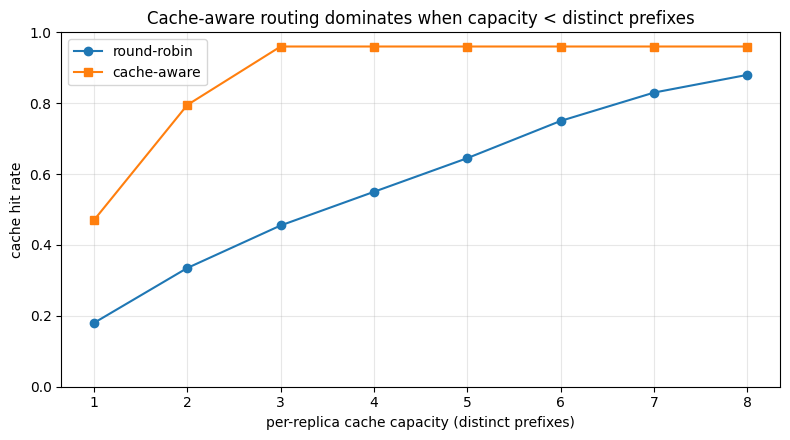

8 distinct system prompts, 3 replicas, 200 requests.
As per-replica capacity grows past the working set, both converge.
Below that threshold, cache-aware keeps prefixes pinned to consistent replicas.


In [7]:
# Visualize how hit rate evolves as replica capacity changes.
caps = list(range(1, 9))
rr_rates, ca_rates = [], []
for cap in caps:
    global REPLICA_CAPACITY
    REPLICA_CAPACITY = cap
    rr_rates.append(run(round_robin_router)["hit_rate"])
    ca_rates.append(run(cache_aware_router)["hit_rate"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(caps, rr_rates, marker="o", label="round-robin")
ax.plot(caps, ca_rates, marker="s", label="cache-aware")
ax.set_xlabel("per-replica cache capacity (distinct prefixes)")
ax.set_ylabel("cache hit rate")
ax.set_title("Cache-aware routing dominates when capacity < distinct prefixes")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"8 distinct system prompts, {NUM_REPLICAS} replicas, 200 requests.")
print("As per-replica capacity grows past the working set, both converge.")
print("Below that threshold, cache-aware keeps prefixes pinned to consistent replicas.")


## Experiments: try these

1. **Rework the memory budget.** Using the formula in cell 5, compute how many *full* 128K-token Llama-3 70B contexts fit in a B200's 180 GB of VRAM after reserving 140 GB for weights and activations. Then compute how many 8K-token contexts fit. The ratio explains why production deployments often cap context length.

2. **Implement radix prefix matching.** The simulator in cell 13 matches whole prefixes with string equality. Replace the `OrderedDict` cache with a trie so that two requests sharing only the first few thousand tokens still get partial credit. Measure the hit-rate lift on a traffic pattern where prompts share a 5K system prompt but diverge in a 1K user section.

3. **Model the G4 fallback.** Extend the routing simulator so that on a local miss, the replica can fetch the cache block from a global G4 store at 12.5 GB/s instead of re-prefilling. At what prefix length does G4-reload beat re-prefill? Does cache-aware routing still matter once G4 is available?


## Key takeaways

- **Prefix caching reuses KV entries across requests when they share a token-level prefix.** Savings land in TTFT, not in throughput — each cached token is one that does not need to be prefilled.
- **The prefix ends at the first non-matching token.** Structure prompts so variable fields (user IDs, query parameters, timestamps) live at the end.
- **KV cache size per token scales with `num_layers * 2 * num_kv_heads * head_dim * dtype_bytes`.** Grouped-query attention cuts this down; long contexts blow it up linearly.
- **A memory hierarchy exists because VRAM fills fast.** G1 → G2 (host RAM, fast on GB200) → G3 (local SSD) → G4 (networked, shared across replicas). Offload decisions are breakeven against re-prefill throughput.
- **Cache-aware routing beats round-robin whenever traffic has shared prefixes and per-replica capacity is smaller than the working set.** Hash prefixes to replicas, but keep load-balancing as a tie-break.

Next: Day 17 — Model Parallelism (Tensor and Expert), which is what happens when a single model's weights and KV cache no longer fit on one GPU.

## References

- *Inference Engineering* Ch 5.3 (pp. 136–141) — Philip Kiely
- NVIDIA Dynamo KV Block Manager (KVBM) — https://github.com/ai-dynamo/dynamo
- CacheBlend: Fast Large Language Model Serving for RAG with Cached Knowledge Fusion (EuroSys 2025)
- LMCache project — https://github.com/LMCache/LMCache
- SGLang RadixAttention (Day 10 notebook in this series)
